## Graph creation

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox


def create_city_graph(place="Helsinki, Finland"):

    G = ox.graph_from_place(
        place,
        network_type="drive",
        simplify=True
    )

    nodes = list(G.nodes)
    node_index = {n:i for i,n in enumerate(nodes)}

    coords = np.array([
        [G.nodes[n]["x"], G.nodes[n]["y"]]
        for n in nodes
    ])

    return G, nodes, node_index, coords

## Turn classification

In [2]:
def classify_turn(p1, p2, p3):

    v1 = p2 - p1
    v2 = p3 - p2

    cross = v1[0]*v2[1] - v1[1]*v2[0]
    dot = v1 @ v2

    angle = np.arctan2(cross, dot)

    if abs(angle) < np.deg2rad(10):
        return "straight"
    elif angle > 0:
        return "left"
    else:
        return "right"

## Build transition matrices

In [3]:
def build_mdp(G, nodes, node_index, coords):

    N = len(nodes)

    neighbors = []
    costs = []

    for n in nodes:

        succ = list(G.successors(n))

        idx = [node_index[s] for s in succ]

        c = []

        for s in succ:

            p1 = coords[node_index[n]]
            p2 = coords[node_index[s]]

            dist = np.linalg.norm(p2-p1)

            travel_time = dist/10

            # simplified: treat all as straight
            wait = 40

            cost = travel_time + wait

            c.append(cost)

        neighbors.append(np.array(idx))
        costs.append(np.array(c))

    return neighbors, costs

## Value iteration

In [4]:
def value_iteration(neighbors, costs, gamma=0.95, cost_per_step=40.0, track_history=True, iter_after_conv=1):

    N = len(neighbors)

    V = np.ones(N) * (cost_per_step / (1 - gamma))  # Upper bound
    V[0] = 0
    conv_iter = 0

    V_history = []
    Q_history = []
    conv = []

    while True:

        delta = 0
        Q = []
        V_old = V.copy()

        for s in range(N):

            if len(neighbors[s]) == 0:
                Q.append([])
                continue

            # Bellman update with costs
            q = -costs[s] + gamma * V_old[neighbors[s]]

            v_new = np.max(q)

            if s == 0: 
                v_new = 0

            delta = max(delta, abs(V_old[s] - v_new))

            V[s] = v_new

            Q.append(q)

        if track_history:
            V_history.append(V.copy())
            Q_history.append(Q.copy())
            conv.append(delta)

        if delta < 1e-6 and iter_after_conv >= conv_iter:
            break
        elif delta < 1e-6: conv_iter += 1
        else: iter_after_conv = 0

    policy = []

    for s in range(N):

        if len(neighbors[s]) == 0:
            policy.append(None)
            continue

        q = -costs[s] + gamma * V[neighbors[s]]

        policy.append(neighbors[s][np.argmax(q)])

    policy[0] = None

    return V, policy, V_history, Q_history, conv

## Policy evaluation

In [5]:
def policy_evaluation(policy, neighbors, costs, gamma=0.99, track_history=False, cost_per_step=40.0):

    N = len(neighbors)

    V = np.ones(N) * (cost_per_step / (1 - gamma))
    # V = np.zeros(N)

    V[0] = 0

    V_history = []

    for _ in range(1000):

        for s in range(1, N):

            a = policy[s]

            if a is None:
                continue

            idx = np.where(neighbors[s] == a)[0][0]

            V[s] = -costs[s][idx] + gamma * V[a]

        if track_history:
            V_history.append(V.copy())

    V[0] = 0

    if track_history:
        return V, V_history
    else:
        return V    

## Policy iteration

In [6]:
def policy_iteration(neighbors, costs, gamma=0.99, track_history=True):

    N = len(neighbors)

    policy = []

    for s in range(N):
        if len(neighbors[s]) == 0:
            policy.append(None)
        else:
            policy.append(neighbors[s][0])

    V_history = []
    Q_history = []
    conv = []

    while True:

        V = policy_evaluation(policy, neighbors, costs, gamma)

        stable = True
        delta = 0

        Q = []

        for s in range(N):

            if len(neighbors[s]) == 0:
                Q.append([])
                continue

            q = -costs[s] + gamma * V[neighbors[s]]

            best_next = neighbors[s][np.argmax(q)]

            if best_next != policy[s]:
                stable = False

            delta = max(delta, np.max(np.abs(q)))

            policy[s] = best_next

            Q.append(q)

        if track_history:
            V_history.append(V.copy())
            Q_history.append(Q.copy())
            conv.append(delta)

        if stable:
            break

    policy[0] = None

    return V, policy, V_history, Q_history, conv

## Q-learning

In [7]:
def q_learning(neighbors, costs, start, goal,
               episodes=2000,
               alpha=0.1,
               gamma=0.99,
               eps=0.1,
               track_history=True, 
               cost_per_step=40.0):

    N = len(neighbors)
    max_actions = max((len(n) for n in neighbors if any(n)), default=0)

    # Q = np.ones((N, max_actions)) * (cost_per_step / (1 - gamma))
    # Q[0, :] = 0
    Q = np.zeros((N, max_actions))

    V_history = []
    Q_history = []
    conv = []

    for ep in range(episodes):

        Q_old = Q.copy()

        s = start

        while s != goal:

            # epsilon-greedy exploration
            if np.random.rand() < eps:
                a_idx = np.random.randint(len(neighbors[s]))
            else:
                a_idx = np.argmax(Q[s, :len(neighbors[s])])

            s_next = neighbors[s][a_idx]

            r = -costs[s][a_idx]

            # future value
            if s_next == goal:
                max_future_q = 0.0
            else:
                max_future_q = np.max(Q[s_next, :len(neighbors[s_next])])

            # Q-learning update
            Q[s, a_idx] += alpha * (r + gamma * max_future_q - Q[s, a_idx])

            s = s_next

        # ---- record history ----
        if track_history:

            V = np.zeros(N)

            for i in range(N):

                na = len(neighbors[i])

                if na == 0:
                    continue

                V[i] = np.max(Q[i, :na])

            V_history.append(V.copy())
            Q_history.append(Q.copy())

            conv.append(np.max(np.abs(Q - Q_old)))

    # ---- policy extraction ----
    policy = []

    for s in range(N):

        n_actions = len(neighbors[s])

        if n_actions == 0 or s == goal:
            policy.append(None)
        else:
            policy.append(np.argmax(Q[s, :n_actions]))

    policy = np.array(policy, dtype=object)

    policy[0] = None

    return Q, policy, V_history, Q_history, conv

### njitted

In [8]:
from numba import njit, prange


def pad_arrays(neighbors, costs):

    N = len(neighbors)
    max_actions = max(len(n) for n in neighbors)

    neigh = -np.ones((N,max_actions), dtype=np.int64)
    c = np.zeros((N,max_actions))
    n_actions = np.zeros(N, dtype=np.int64)

    for i in range(N):

        na = len(neighbors[i])
        n_actions[i] = na

        neigh[i,:na] = neighbors[i]
        c[i,:na] = costs[i]

    return neigh, c, n_actions

@njit
def q_learning_njit(neighbors,
               costs,
               n_actions,
               start,
               goal,
               episodes,
               alpha,
               gamma,
               eps,
               max_iters=1_000_000,
               cost_per_step = 40.0):

    N = neighbors.shape[0]
    max_actions = neighbors.shape[1]

    # Q = np.ones((N, max_actions)) * (cost_per_step / (1 - gamma))
    # Q[0, :] = 0
    Q = np.zeros((N, max_actions))

    V_history = np.zeros((episodes, N))
    Q_history = np.zeros((episodes, N, max_actions))
    conv = np.zeros(episodes)

    for ep in range(episodes):

        Q_old = Q.copy()

        s = start
        iter = 0

        while s != goal:

            iter += 1
            if iter >= max_iters: break

            na = n_actions[s]

            if na == 0:
                break

            if np.random.rand() < eps:
                a = np.random.randint(na)
            else:
                best = 0
                best_val = Q[s,0]
                for i in range(1,na):
                    if Q[s,i] > best_val:
                        best_val = Q[s,i]
                        best = i
                a = best

            s_next = neighbors[s,a]

            r = -costs[s,a]

            if s_next == goal:
                max_future_q = 0.0
            else:
                na_next = n_actions[s_next]

                max_future_q = Q[s_next,0]

                for i in range(1,na_next):
                    if Q[s_next,i] > max_future_q:
                        max_future_q = Q[s_next,i]

            Q[s,a] += alpha * (r + gamma * max_future_q - Q[s,a])

            s = s_next

        # record history
        for i in range(N):
            best = Q[i,0]-1000
            for j in range(0,max_actions):
                if Q[i,j] > best:
                    best = Q[i,j]
            V_history[ep,i] = best

        Q_history[ep,:,:] = Q

        maxdiff = 0.0
        for i in range(N):
            for j in range(max_actions):
                d = abs(Q[i,j]-Q_old[i,j])
                if d > maxdiff:
                    maxdiff = d

        conv[ep] = maxdiff

    policy = np.empty(N, dtype=np.int64)

    for s in range(N):

        na = n_actions[s]

        if na == 0 or s == goal:
            policy[s] = -1
        else:

            best = 0
            best_val = Q[s,0]

            for i in range(1,na):
                if Q[s,i] > best_val:
                    best_val = Q[s,i]
                    best = i

            policy[s] = best

    policy[0] = np.nan

    return Q, policy, V_history, Q_history, conv

# Build costs

In [9]:
LEFT_WAIT = 60
RIGHT_WAIT = 20
STRAIGHT_WAIT = 40

SPEED = 100.0

def build_neighbors_costs(G, nodes, node_index, turns):

    neighbors = []
    costs = []

    for u in nodes:

        succ = list(G.successors(u))

        next_ids = []
        edge_costs = []

        for v in succ:

            next_ids.append(node_index[v])

            # base travel cost
            p1 = G.nodes[u]["pos"]
            p2 = G.nodes[v]["pos"]

            dist = np.linalg.norm(p2 - p1)
            travel_time = dist / SPEED

            # turn penalty (approximate)
            turn_type = "straight"

            preds = list(G.predecessors(u))

            if preds:
                p = preds[0]

                triple = (p, u, v)

                if triple in turns:
                    turn_type = turns[triple]

            if turn_type == "left":
                wait = LEFT_WAIT
            elif turn_type == "right":
                wait = RIGHT_WAIT
            else:
                wait = STRAIGHT_WAIT

            edge_costs.append(travel_time + wait)

        neighbors.append(np.array(next_ids, dtype=int))
        costs.append(np.array(edge_costs))

    return neighbors, costs

## Artificial graph

In [10]:
import networkx as nx

def create_artificial_graph(n=4):

    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            G.add_node((i,j), pos=np.array([i,j]))

    for i in range(n):
        for j in range(n):

            if i+1 < n:
                G.add_edge((i,j),(i+1,j))
                G.add_edge((i+1,j),(i,j))

            if j+1 < n:
                G.add_edge((i,j),(i,j+1))
                G.add_edge((i,j+1),(i,j))

    return G

## Download real city graph

In [11]:
import osmnx as ox

def create_city_graph(place="Helsinki, Finland"):

    G = ox.graph_from_place(
        place,
        network_type="drive",
        simplify=True
    )

    # store coordinates as numpy arrays
    for n,data in G.nodes(data=True):
        data["pos"] = np.array([data["x"], data["y"]])

    return G

##  Detect turn types

In [12]:
def detect_turns(G):

    turns = {}

    for v in G.nodes:

        preds = list(G.predecessors(v))
        succs = list(G.successors(v))

        for u in preds:
            for w in succs:

                if u == w:
                    continue

                p1 = G.nodes[u]["pos"]
                p2 = G.nodes[v]["pos"]
                p3 = G.nodes[w]["pos"]

                turn = classify_turn(p1,p2,p3)

                turns[(u,v,w)] = turn

    return turns

# Graph to numpy

In [13]:
def graph_to_numpy(G):

    nodes = list(G.nodes)
    node_index = {n:i for i,n in enumerate(nodes)}

    coords = np.array([G.nodes[n]["pos"] for n in nodes])

    neighbors = []

    for n in nodes:

        succ = list(G.successors(n))

        neighbors.append(
            np.array([node_index[s] for s in succ])
        )

    return nodes, node_index, coords, neighbors

# Visualization

In [14]:
import matplotlib.pyplot as plt

def visualize_graph(G, V, policy, nodes, node_index, turns, node_size=250, show_node_id=False, arrowwidth=2.5, show_trajectory_only=False, start=0):

    pos = {n:G.nodes[n]["pos"] for n in G.nodes}

    values = np.array([V[node_index[n]] for n in nodes])

    fig, ax = plt.subplots(figsize=(14,10))

    # draw nodes colored by value
    node_plot = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=values,
        cmap="plasma",
        node_size=node_size,
        ax=ax
    )

# draw normal edges
    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.3,
        arrows=True,
        ax=ax
    )

    # draw policy arrows (red)
    policy_edges=[]
    policy_turns=[]

    for s,a in enumerate(policy):

        if a is None:
            continue

        u = nodes[s]
        v = nodes[a]

        policy_edges.append((u,v))

    if show_trajectory_only:

        traj=[]
        s=start

        visited=set()

        while s is not None and s not in visited:

            visited.add(s)

            a=policy[s]

            if a is None:
                break

            next_s = nodes[a]

            traj.append((nodes[s], next_s))

            if (policy[a] is not None) and (not np.isnan(policy[a])): 
                w = nodes[policy[a]]
                if (w is not None) and (not np.isnan(policy[a])): 
                    policy_turns.append((nodes[s],nodes[a],w))

            s=a

        nx.draw_networkx_edges(G,pos,edgelist=traj,
                            edge_color="red",
                            width=3,
                            arrows=True,
                            ax=ax)

    else:

        nx.draw_networkx_edges(G,pos,
                            edgelist=policy_edges,
                            edge_color="red",
                            width=2.5,
                            arrows=True,
                            ax=ax)

    # draw node labels
    if show_node_id:
        nx.draw_networkx_labels(
            G,
            pos,
            font_size=7,
            ax=ax
        )

    # draw turn symbols
    for (u,v,w) in policy_turns:
        if u==v or u==w or v==w: continue
        t = turns[(u,v,w)]

        p1 = pos[u]
        p2 = pos[v]
        p3 = pos[w]

        mid = (p1 + p2) / 2

        if t=="left":
            symbol="←"
            color="blue"

        elif t=="right":
            symbol="→"
            color="green"

        else:
            symbol="↑"
            color="gray"

        ax.text(
            mid[0],
            mid[1],
            symbol,
            color=color,
            fontsize=20,
            ha="center",
            va="center"
        )

    # proper colorbar
    fig.colorbar(node_plot, ax=ax, label="Value")

    ax.set_title("Policy + Value Function + Turn Detection")

    ax.axis("off")

    plt.show()

In [15]:
def plot_convergence(V_history, Q_history, conv, action_names=None):

    max_v = np.max([len(V_history[i]) for i in range(len(V_history))])
    n_q = np.max([len(Q_history[i]) for i in range(len(Q_history))])
    # max_q = np.max([len(Q_history[i]) for i in range(len(Q_history))])
    V_arr = np.empty((len(V_history), max_v))
    for i, v in enumerate(V_history):
        V_arr[i][:len(v)] = v
        V_arr[i][len(v):] = v[-1]
    Q_arr = np.empty((len(Q_history), n_q, max_v))
    for i, q in enumerate(Q_history):
        for j in range(len(q)):
            Q_arr[i, j][:len(q[j])] = q[j]
            Q_arr[i, j][len(q[j]):] = q[j][-1]

    iters = np.arange(len(V_arr))

    NUM_STATES = V_arr.shape[1]
    NUM_ACTIONS = Q_arr.shape[2]

    fig, axes = plt.subplots(1,3,figsize=(18,5))

    # V convergence
    ax=axes[0]

    colors = plt.cm.tab10(np.linspace(0,1,min(NUM_STATES, 25)))

    for s in range(min(NUM_STATES, 25)):
        ax.plot(iters,V_arr[:,s],color=colors[s],linewidth=2,label=f"s={s}")

    ax.set_title("V(s) convergence")
    ax.set_xlabel("iteration")
    ax.set_ylabel("V(s)")
    ax.grid(True)
    ax.legend(fontsize=7)

    # Q convergence
    ax=axes[1]

    linestyles=['-','--',':','-.']

    for s in range(min(NUM_STATES, 25)):

        for a in range(NUM_ACTIONS):

            ax.plot(iters,Q_arr[:,s,a],
                    color=colors[s],
                    linestyle=linestyles[a%4],
                    alpha=0.7)

    ax.set_title("Q(s,a) convergence")
    ax.set_xlabel("iteration")
    ax.set_ylabel("Q(s,a)")
    ax.grid(True)

    # convergence metric
    ax=axes[2]

    ax.semilogy(conv,color="crimson",linewidth=2)

    ax.set_title("max update per iteration")
    ax.set_xlabel("iteration")
    ax.set_ylabel("||Δ||∞")

    ax.grid(True)

    plt.tight_layout()
    plt.show()

## Run artificial

In [16]:
# %matplotlib widget

### Value iteration

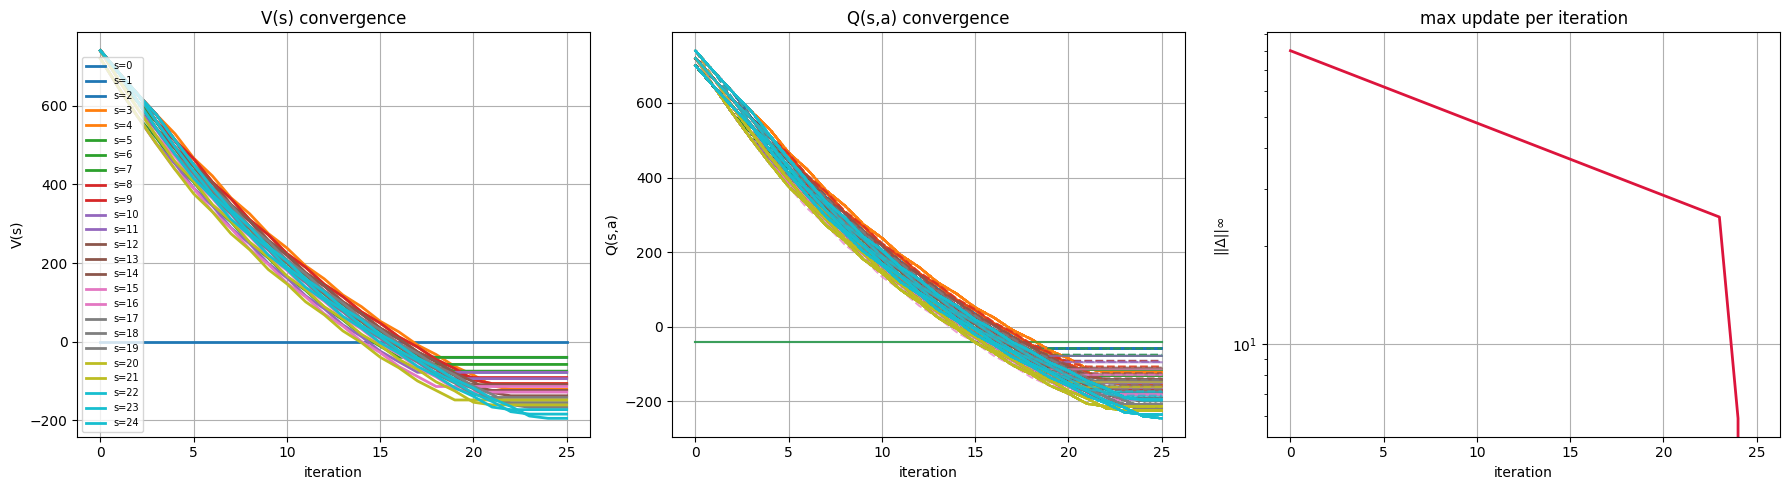

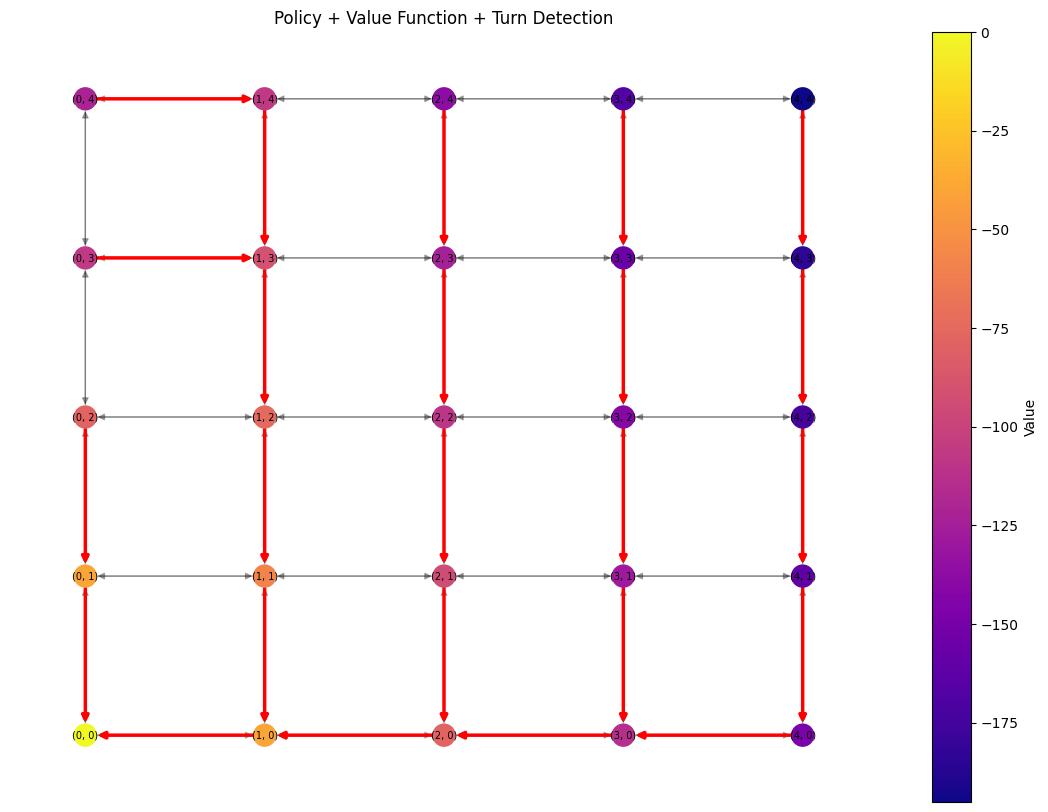

In [17]:
G = create_artificial_graph(5)

turns = detect_turns(G)

nodes,node_index,coords,neighbors = graph_to_numpy(G)

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

V,policy, Vh, Qh, conv = value_iteration(neighbors, costs)

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy,nodes,node_index,turns, show_node_id=True, start=len(nodes)-1, show_trajectory_only=False)

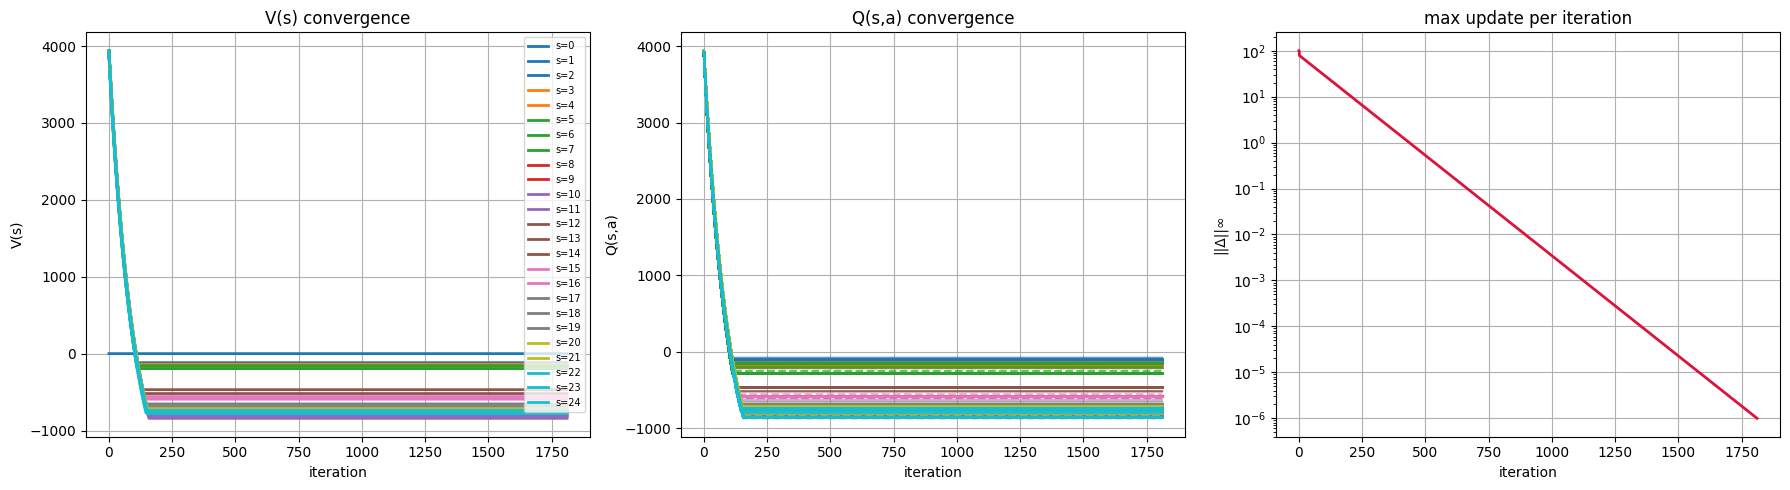

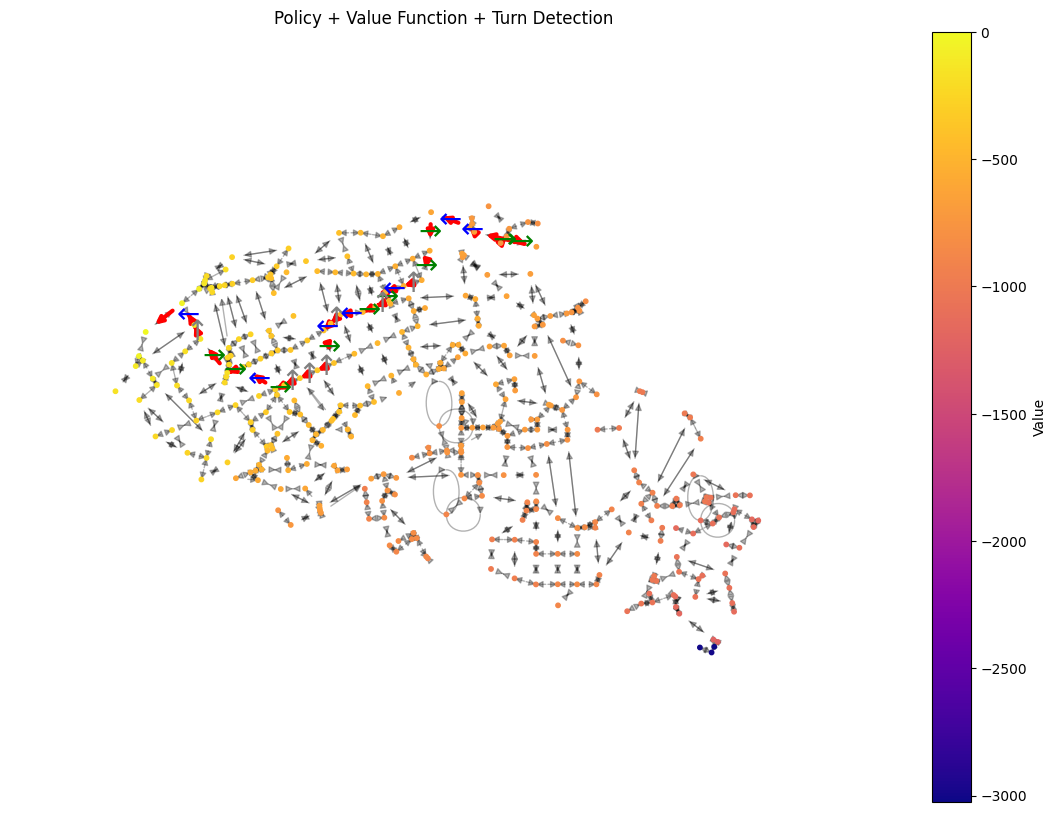

In [18]:
G = create_city_graph("Piedmont, California, USA")
# Helsinki, Finland
# Piedmont, California, USA

turns = detect_turns(G)

nodes,node_index,coords,neighbors = graph_to_numpy(G)

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

V,policy, Vh, Qh, conv = value_iteration(neighbors, costs, gamma=0.99)

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy,nodes,node_index,turns, node_size=10, show_node_id=False, arrowwidth=0.5,
                start=len(nodes)-1, show_trajectory_only=True)

### Policy iteration

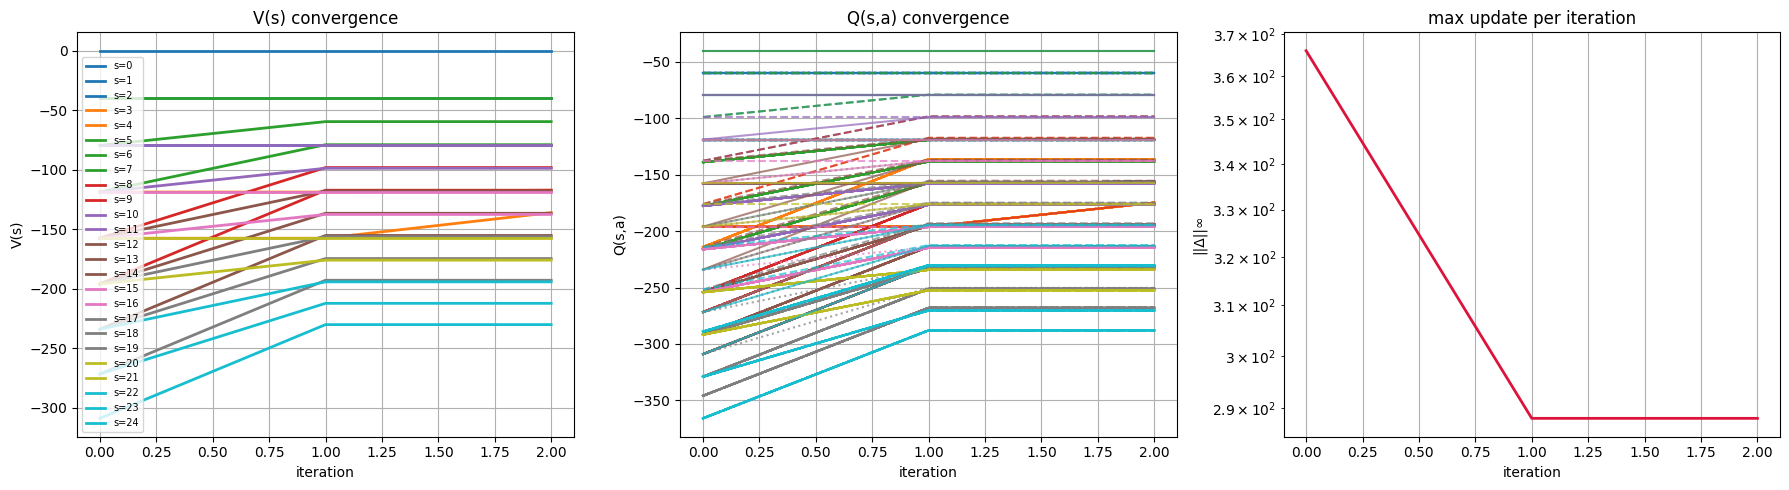

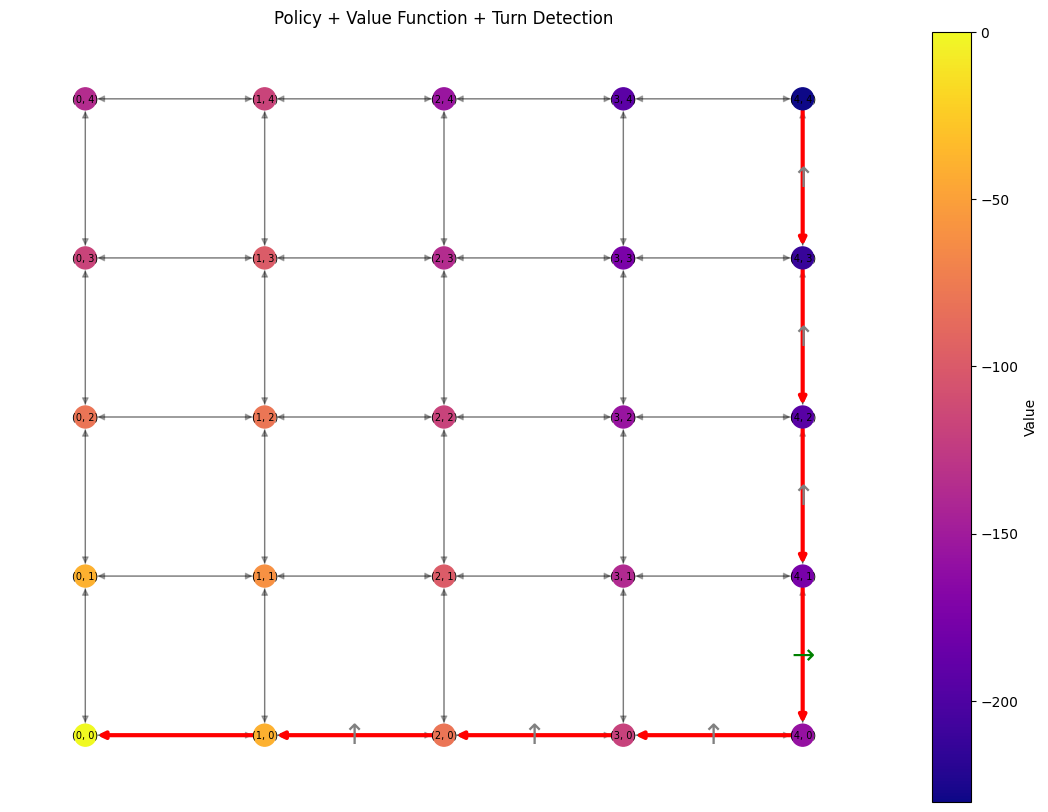

In [19]:
G = create_artificial_graph(5)

turns = detect_turns(G)

nodes, node_index, coords, neighbors = graph_to_numpy(G)

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

V, policy, Vh, Qh, conv = policy_iteration(neighbors, costs, gamma=0.99)

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy,nodes,node_index,turns, show_node_id=True,
                start=len(nodes)-1, show_trajectory_only=True)

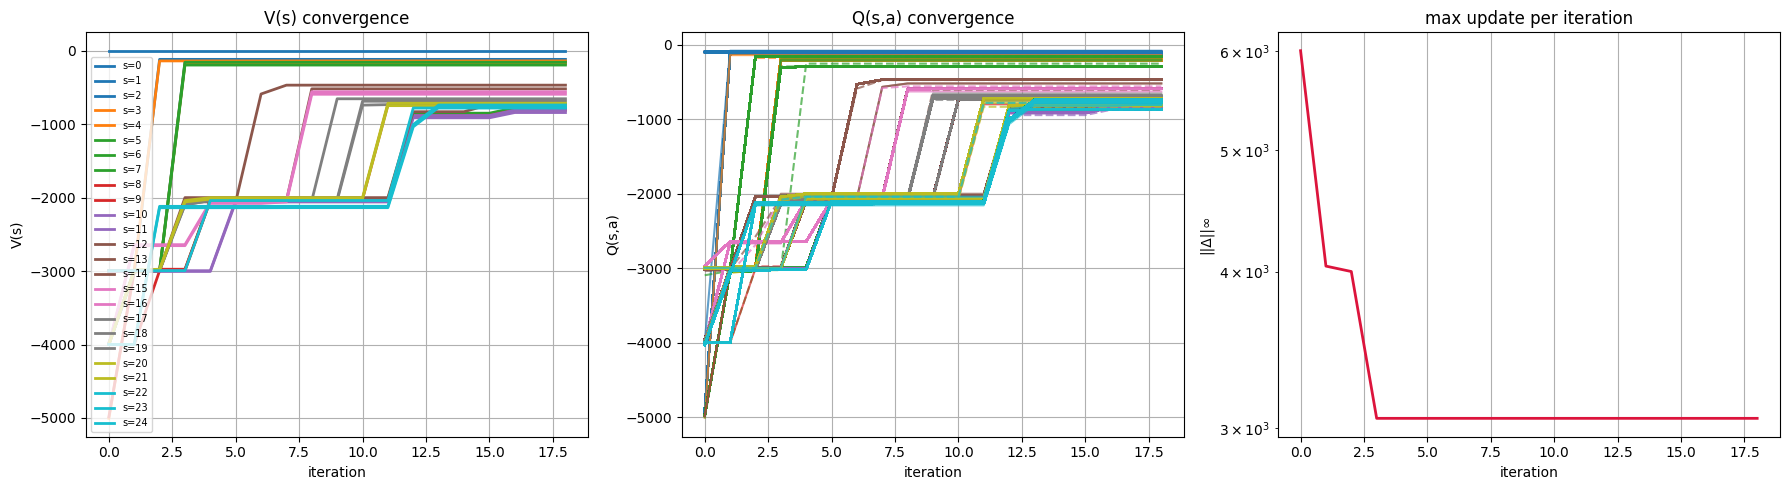

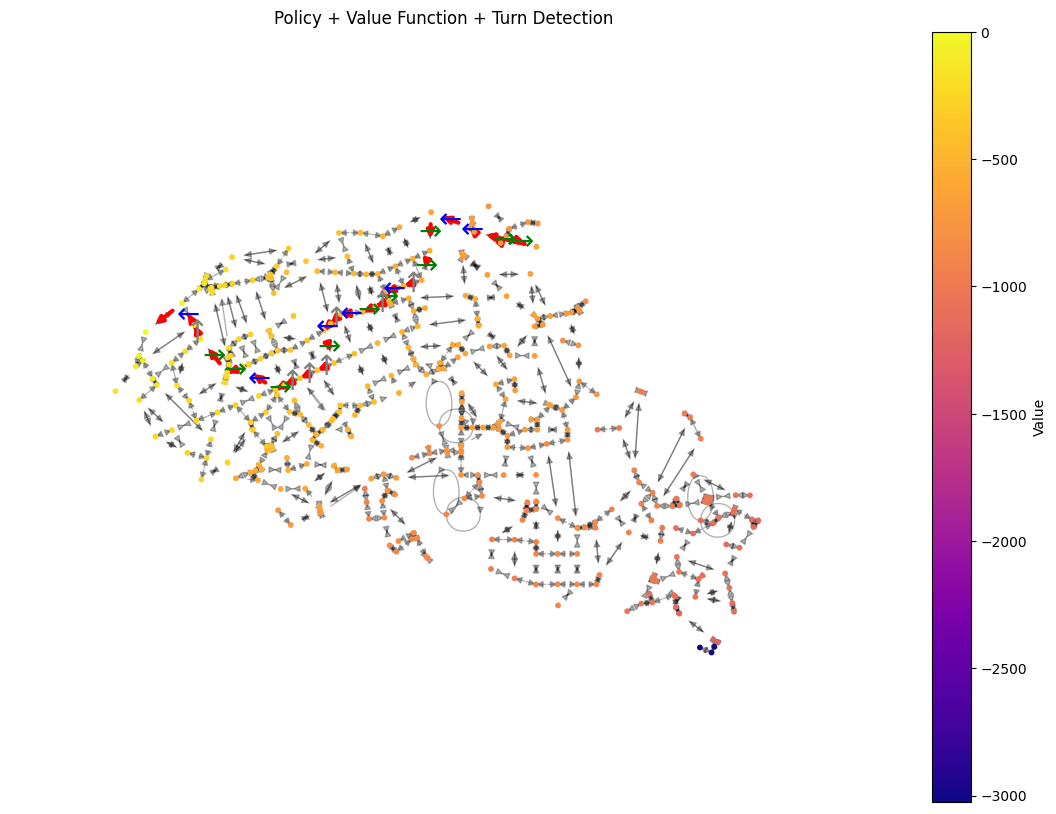

In [20]:
G = create_city_graph("Piedmont, California, USA")

turns = detect_turns(G)

nodes, node_index, coords, neighbors = graph_to_numpy(G)

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

V, policy, Vh, Qh, conv = policy_iteration(neighbors, costs)

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy,nodes,node_index,turns, node_size=10, show_node_id=False, arrowwidth=0.5,
                start=len(nodes)-1, show_trajectory_only=True)

### Q-learning with value iteration

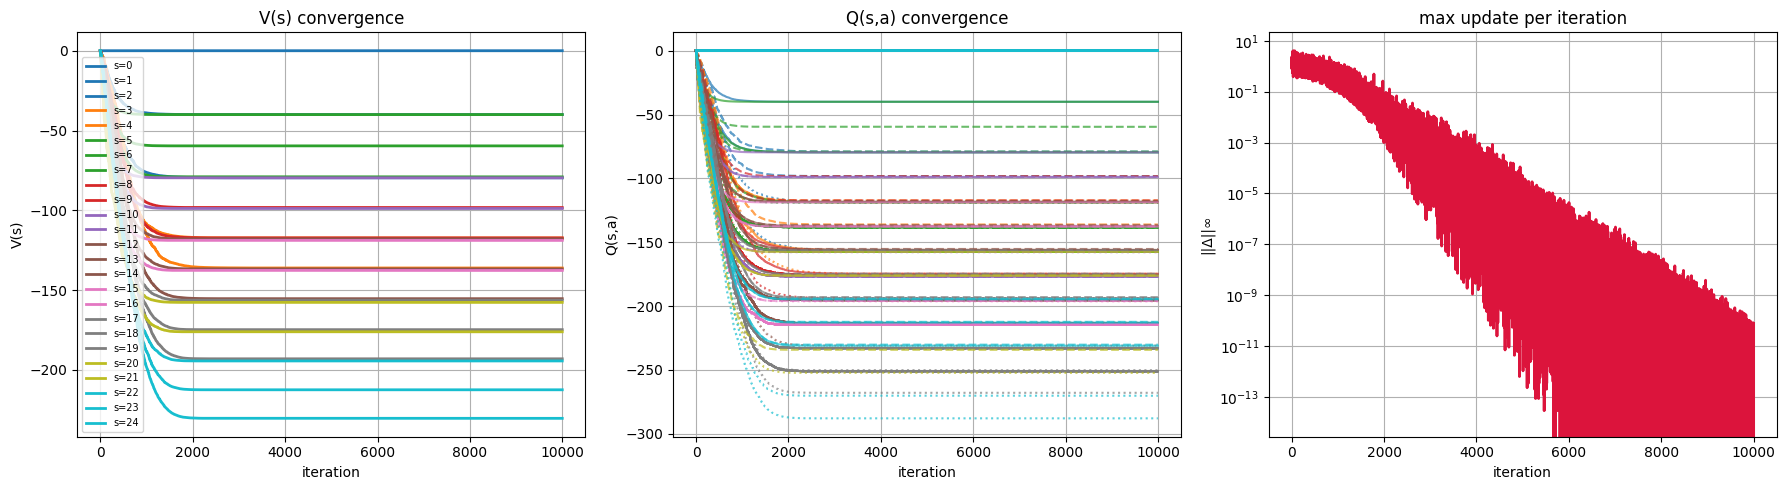

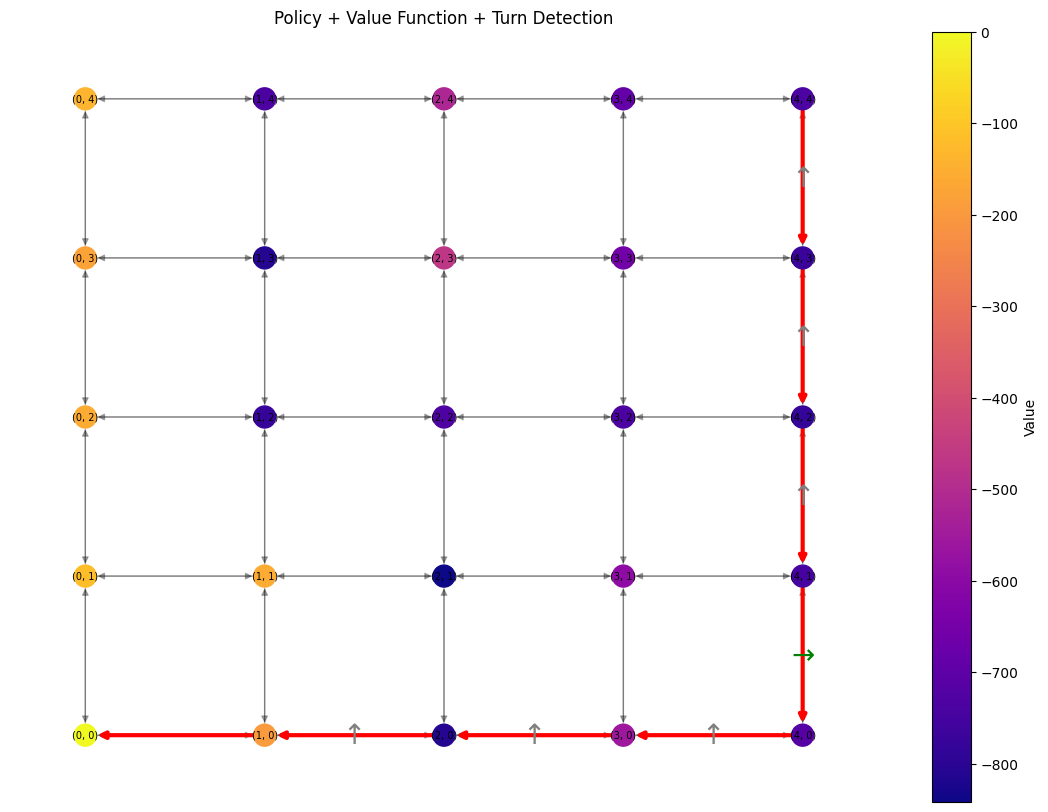

In [21]:
G = create_artificial_graph(5)

turns = detect_turns(G)

nodes, node_index, coords, neighbors = graph_to_numpy(G)

start = len(nodes) - 1
goal = 0

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

Q, policy, Vh, Qh, conv = q_learning(
    neighbors,
    costs,
    start,
    goal,
    episodes=10000,
    alpha=1e-2,
    gamma=0.99,
    eps=0.9
)

# Actions to states for visualization
policy_nodes = []

for s, a in enumerate(policy):

    if a is None:
        policy_nodes.append(None)
    else:
        policy_nodes.append(neighbors[s][a])

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy_nodes,nodes,node_index,turns, show_node_id=True,
                start=len(nodes)-1, show_trajectory_only=True)

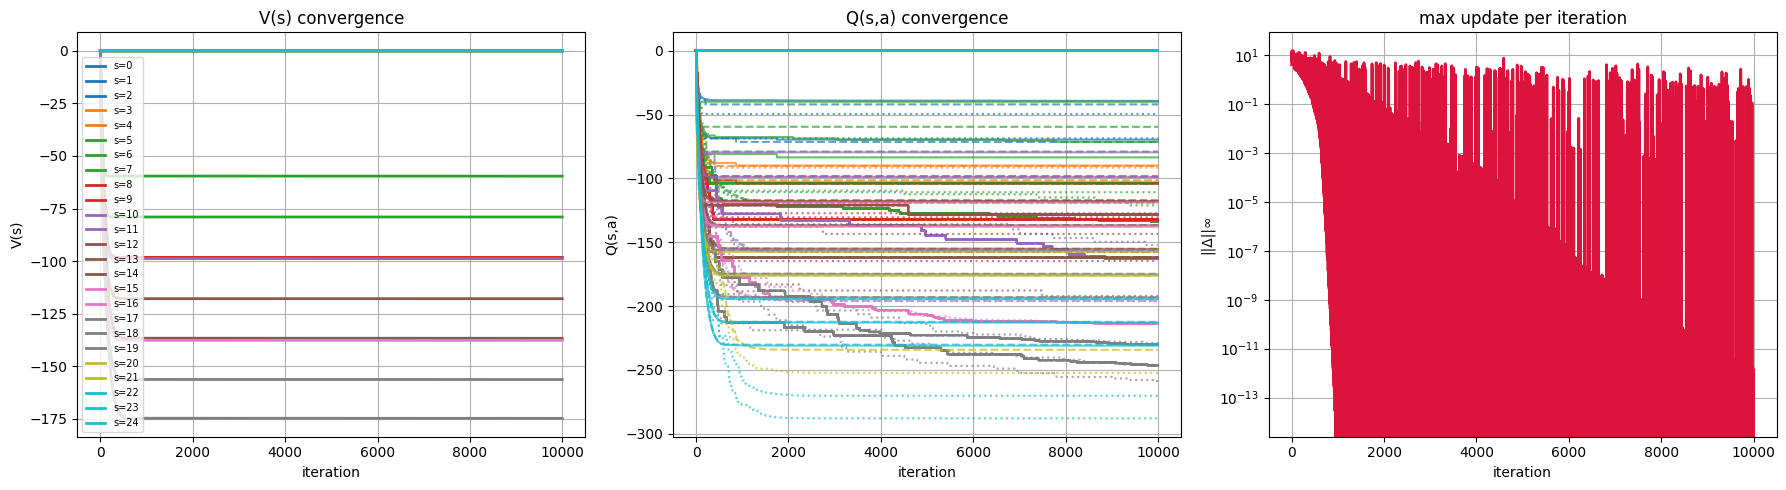

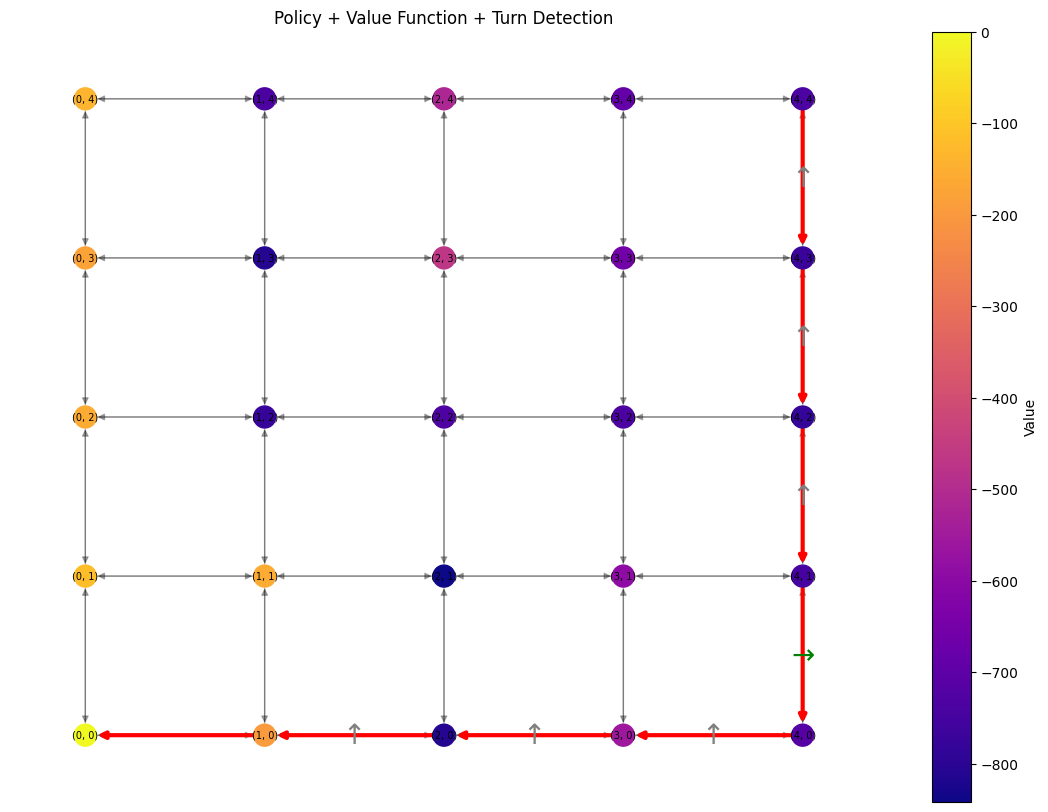

In [22]:


G = create_artificial_graph(5)

turns = detect_turns(G)

nodes, node_index, coords, neighbors = graph_to_numpy(G)

start = len(nodes) - 1
goal = 0

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

neighbors_arr, costs_arr, n_actions = pad_arrays(neighbors, costs)

Q, policy, Vh, Qh, conv = q_learning_njit(
    neighbors_arr,
    costs_arr,
    n_actions,
    start,
    goal,
    episodes=10000,
    alpha=0.1,
    gamma=0.99,
    eps=0.1
)

# Actions to states for visualization
policy_nodes = []

for s, a in enumerate(policy):

    if a is None or a < 0 or np.isnan(a):
        policy_nodes.append(None)
    else:
        policy_nodes.append(neighbors[s][a])

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy_nodes,nodes,node_index,turns, show_node_id=True,
                start=len(nodes)-1, show_trajectory_only=True)

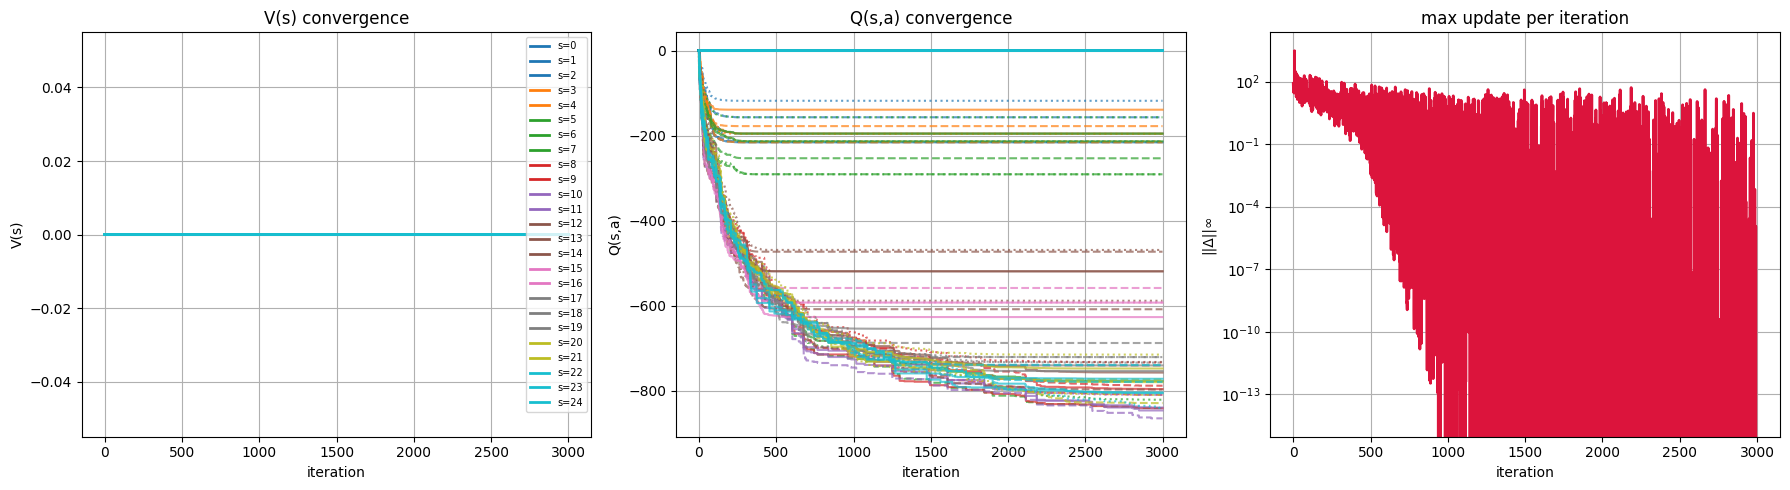

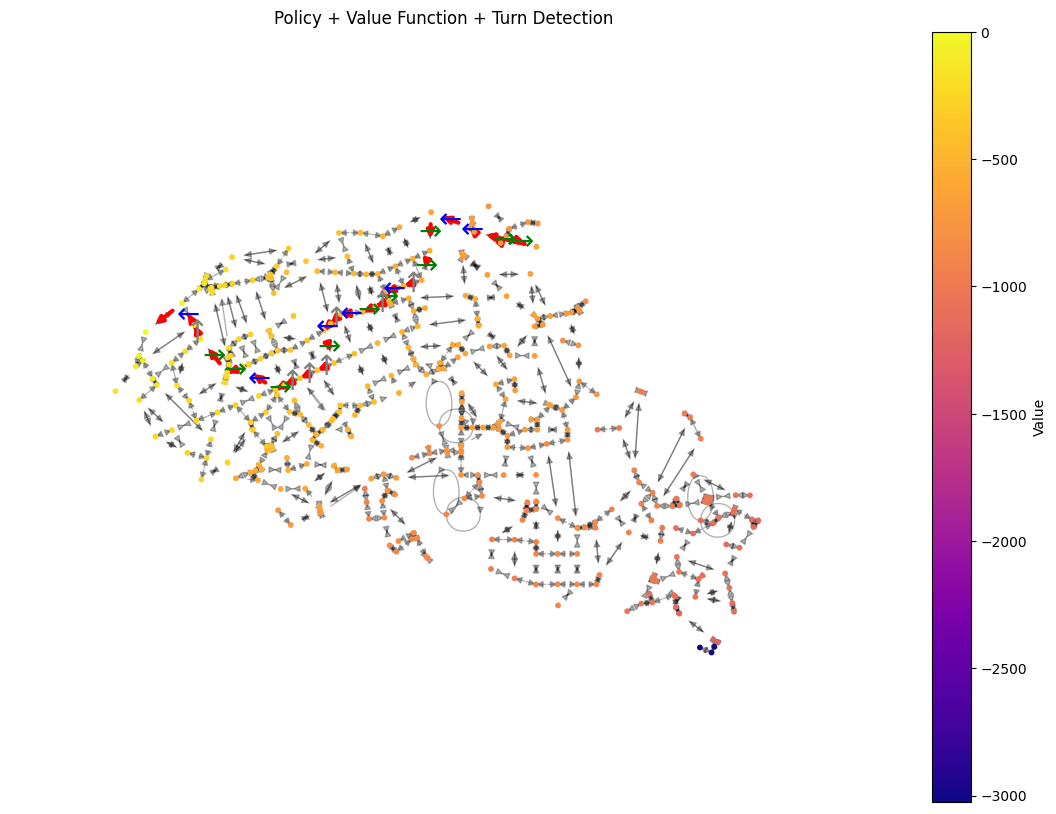

In [23]:
G = create_city_graph("Piedmont, California, USA")

turns = detect_turns(G)

nodes, node_index, coords, neighbors = graph_to_numpy(G)

start = len(nodes) - 1
goal = 0

neighbors, costs = build_neighbors_costs(G, nodes, node_index, turns)

neighbors_arr, costs_arr, n_actions = pad_arrays(neighbors, costs)

Q, policy, Vh, Qh, conv = q_learning_njit(
    neighbors_arr,
    costs_arr,
    n_actions,
    start,
    goal,
    episodes=3_000,
    alpha=0.1,
    gamma=0.99,
    eps=0.9
)

# Actions to states for visualization
policy_nodes = []

for s, a in enumerate(policy):

    if a is None or a < 0 or np.isnan(a):
        policy_nodes.append(None)
    else:
        policy_nodes.append(neighbors[s][a])

plot_convergence(Vh, Qh, conv)

visualize_graph(G,V,policy_nodes,nodes,node_index,turns, node_size=10, show_node_id=False, arrowwidth=0.5,
                start=len(nodes)-1, show_trajectory_only=True)

In [24]:
Vh

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3000, 352))